# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

## Task 1.1: Nasdaq Multi-Feature Extension

This section implements stock price prediction using multiple features (Low, High, Open, Close, Adjusted Close, Volume) instead of relying solely on the Open price. The model uses a 30-day sliding window to predict the next day's Open price.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

I0000 00:00:1777986282.460837   99380 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777986282.935578   99380 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777986284.640548   99380 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
data_appl = pd.read_csv('AAPL.csv')

In [4]:
data_appl.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [5]:
data_appl.info()

<class 'pandas.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  str    
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), str(1)
memory usage: 579.3 KB


In [6]:
df = data_appl
feature_columns = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
num_features = len(feature_columns)

X_data = []
y_data = []
window_size = 30

for i in range(1, len(df) - window_size - 1):
    data_feature = []
    data_label = []

    for j in range(window_size):
        data_feature.append(df[feature_columns].iloc[i + j].values)

    data_label.append(df['Open'].iloc[i + window_size])

    X_data.append(np.array(data_feature))
    y_data.append(np.array(data_label))


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("Shape of training set: ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set: ", X_test.shape)
print("Number of features: ", X_train.shape[2])

Shape of training set:  (6756, 30, 6)
Shape of validation set:  (1690, 30, 6)
Shape of test set:  (2112, 30, 6)
Number of features:  6


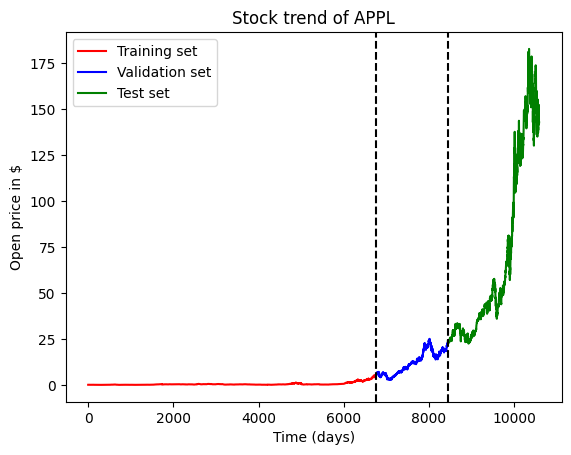

In [8]:
df_plot = df['Open']
df_plot = df_plot.reset_index(drop=False)

size_train = X_train.shape[0]
size_val = X_val.shape[0]
size_test = X_test.shape[0]

ax = df_plot.iloc[:size_train,1:2].plot(y=0, color='red', label='Training set')
df_plot.iloc[size_train:size_train+size_val,1:2].plot(y=0, color='blue', label='Validation set', ax=ax)
df_plot.iloc[size_train+size_val:df_plot.shape[0],1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of APPL")
plt.xlabel('Time (days)')
plt.ylabel('Open price in $')
plt.axvline(x=size_train, color='black', linestyle='--')
plt.axvline(x=size_train+size_val, color='black', linestyle='--')
plt.show()

In [9]:
def normalize_multifeature(X, y):
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    for i in range(len(X)):
        for f in range(X.shape[2]):
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            if denom == 0:
                X_norm[i, :, f] = 0
            else:
                X_norm[i, :, f] = (X[i, :, f] - min_val) / denom

        open_min = np.min(X[i, :, 1])
        open_max = np.max(X[i, :, 1])
        open_denom = open_max - open_min
        if open_denom == 0:
            y_norm[i] = 0
        else:
            y_norm[i] = (y[i] - open_min) / open_denom
    return X_norm, y_norm

X_train_norm, y_train_norm = normalize_multifeature(X_train, y_train)
X_val_norm, y_val_norm = normalize_multifeature(X_val, y_val)

In [10]:
model = tf.keras.Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history = model.fit(X_train_norm, y_train_norm, validation_data=(X_val_norm, y_val_norm), epochs=5, batch_size=512)

/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777986409.270842   99380 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777986409.271029  146037 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777986409.296396   99380 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned ab

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.5272 - mse: 1.5272 - val_loss: 0.1696 - val_mse: 0.1696
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1621 - mse: 0.1621 - val_loss: 0.1630 - val_mse: 0.1630
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1432 - mse: 0.1432 - val_loss: 0.1069 - val_mse: 0.1069
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0986 - mse: 0.0986 - val_loss: 0.0878 - val_mse: 0.0878
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0816 - mse: 0.0816 - val_loss: 0.0611 - val_mse: 0.0611


In [11]:
X_test_norm, y_test_norm = normalize_multifeature(X_test, y_test)
y_pred_norm = model.predict(X_test_norm)
print("MSE on the test set: ", mean_squared_error(y_pred_norm, y_test_norm))

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE on the test set:  0.05965599040016866


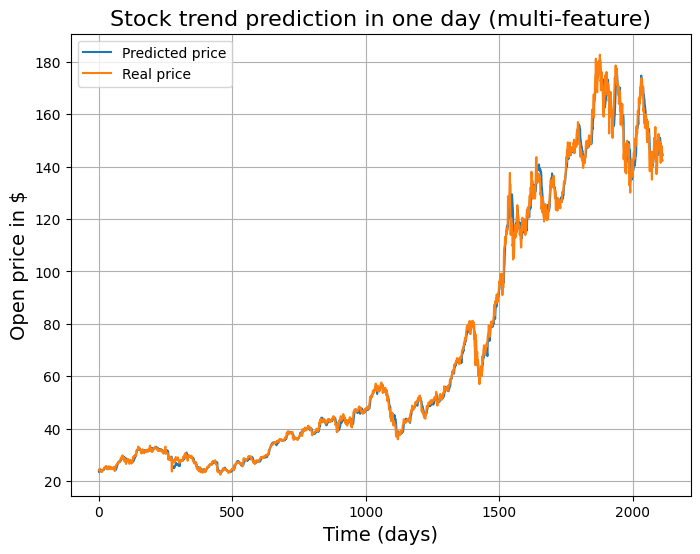

In [12]:
y_pred_denorm = y_pred_norm.copy()
for i in range(0, len(y_pred_denorm)):
    open_min = np.min(X_test[i, :, 1])
    open_max = np.max(X_test[i, :, 1])
    y_pred_denorm[i] = y_pred_norm[i] * (open_max - open_min) + open_min

plt.figure(figsize=(8, 6))
plt.plot(y_pred_denorm, label='Predicted price')
plt.plot(y_test, label='Real price')
plt.title('Stock trend prediction in one day (multi-feature)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()

## Task 1.2: Nasdaq k-th Day Forecast

This section implements the k-th day forecast, predicting the stock price on the k-th day ahead instead of just the next day.

In [13]:
def prepare_data_k(df, feature_columns, window_size, k):
    X_data = []
    y_data = []
    
    for i in range(1, len(df) - window_size - k):
        data_feature = []
        data_label = []
        
        for j in range(window_size):
            data_feature.append(df[feature_columns].iloc[i + j].values)
        
        data_label.append(df['Open'].iloc[i + window_size + k - 1])
        
        X_data.append(np.array(data_feature))
        y_data.append(np.array(data_label))
    
    return np.array(X_data), np.array(y_data)

In [14]:
def train_k(k):
    X_k, y_k = prepare_data_k(df, feature_columns, window_size, k)
    
    X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.2, shuffle=False)
    X_train_k, X_val_k, y_train_k, y_val_k = train_test_split(X_train_k, y_train_k, test_size=0.2, shuffle=False)
    
    print(f"Training set: {X_train_k.shape[0]}, Val: {X_val_k.shape[0]}, Test: {X_test_k.shape[0]}")
    
    X_train_norm_k, y_train_norm_k = normalize_multifeature(X_train_k, y_train_k)
    X_val_norm_k, y_val_norm_k = normalize_multifeature(X_val_k, y_val_k)
    X_test_norm_k, y_test_norm_k = normalize_multifeature(X_test_k, y_test_k)
    
    model_k = tf.keras.Sequential()
    model_k.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
    model_k.add(MaxPooling1D(pool_size=2))
    model_k.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model_k.add(MaxPooling1D(2))
    model_k.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model_k.add(MaxPooling1D(2))
    model_k.add(Flatten())
    model_k.add(Dense(100, activation='relu'))
    model_k.add(Dense(1))
    
    model_k.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
    history_k = model_k.fit(X_train_norm_k, y_train_norm_k, validation_data=(X_val_norm_k, y_val_norm_k), epochs=5, batch_size=512, verbose=1)
    
    y_pred_norm_k = model_k.predict(X_test_norm_k)
    mse_k = mean_squared_error(y_pred_norm_k, y_test_norm_k)
    
    y_pred_denorm_k = y_pred_norm_k.copy()
    for i in range(len(y_pred_denorm_k)):
        open_min = np.min(X_test_k[i, :, 1])
        open_max = np.max(X_test_k[i, :, 1])
        y_pred_denorm_k[i] = y_pred_norm_k[i] * (open_max - open_min) + open_min
    
    return {
        'mse_norm': mse_k,
        'y_pred_denorm': y_pred_denorm_k,
        'y_test': y_test_k,
        'model': model_k,
        'history': history_k
    }

In [15]:
k_values = [1, 3, 5, 7]
results = {}

for k in k_values:
    print(f"\n{'='*50}")
    print(f"Training model for k={k} day ahead prediction")
    print('='*50)
    
    results[k] = train_k(k) 
    print(f"MSE on test set (k={k}): {results[k]["mse_norm"]}")


Training model for k=1 day ahead prediction
Training set: 6756, Val: 1690, Test: 2112
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 3.8549 - mse: 3.8549 - val_loss: 0.1894 - val_mse: 0.1894
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1604 - mse: 0.1604 - val_loss: 0.1197 - val_mse: 0.1197
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1098 - mse: 0.1098 - val_loss: 0.0994 - val_mse: 0.0994
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0821 - mse: 0.0821 - val_loss: 0.0804 - val_mse: 0.0804
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0623 - mse: 0.0623 - val_loss: 0.0473 - val_mse: 0.0473
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE on test set (k=1): 0.048157861325607294

Training model for k=3 day ahead prediction
Training set: 6755, Val: 1689, Test: 2112
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.7425 - mse: 1.7425 - val_loss: 0.2227 - val_mse: 0.2227
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1757 - mse: 0.1757 - val_loss: 0.1131 - val_mse: 0.1131
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1149 - mse: 0.1149 - val_loss: 0.0769 - val_mse: 0.0769
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0902 - mse: 0.0902 - val_loss: 0.0675 - val_mse: 0.0675
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0802 - mse: 0.0802 - val_loss: 0.0655 - val_mse: 0.0655
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE on test set (k=3): 0.0691804327467803

Training model for k=5 day ahead prediction
Training set: 6754, Val: 1689, Test: 2111
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.9705 - mse: 0.9705 - val_loss: 0.2838 - val_mse: 0.2838
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2893 - mse: 0.2893 - val_loss: 0.2773 - val_mse: 0.2773
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2670 - mse: 0.2670 - val_loss: 0.2112 - val_mse: 0.2112
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2107 - mse: 0.2107 - val_loss: 0.1670 - val_mse: 0.1670
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1856 - mse: 0.1856 - val_loss: 0.1522 - val_mse: 0.1522
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on test set (k=5): 0.1524073115549901

Training model for k=7 day ahead prediction
Training set: 6752, Val: 1689, Test: 2111
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.0628 - mse: 1.0628 - val_loss: 0.3174 - val_mse: 0.3174
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3644 - mse: 0.3644 - val_loss: 0.3171 - val_mse: 0.3171
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3407 - mse: 0.3407 - val_loss: 0.2783 - val_mse: 0.2783
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2788 - mse: 0.2788 - val_loss: 0.2149 - val_mse: 0.2149
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2386 - mse: 0.2386 - val_loss: 0.1839 - val_mse: 0.1839
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on test set (k=7): 0.1838605776228173


In [16]:
print("\n=== Task 1.2 Summary: k-th Day Forecast ===")
all_mse = [results[k]['mse_norm'] for k in k_values]
for k, mse in zip(k_values, all_mse):
    print(f"k={k}: MSE = {mse:.6f}")


=== Task 1.2 Summary: k-th Day Forecast ===
k=1: MSE = 0.048158
k=3: MSE = 0.069180
k=5: MSE = 0.152407
k=7: MSE = 0.183861


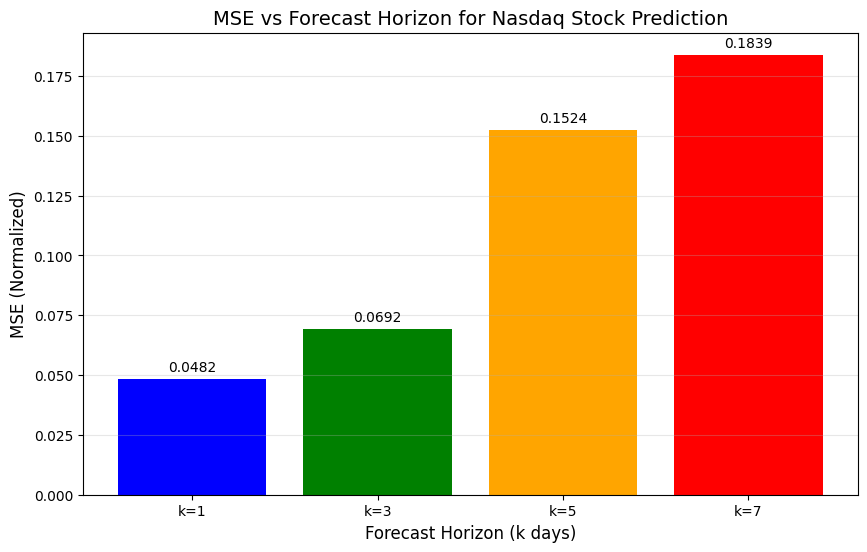

In [17]:
plt.figure(figsize=(10, 6))
bars = plt.bar([f'k={k}' for k in k_values], all_mse, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Forecast Horizon (k days)', fontsize=12)
plt.ylabel('MSE (Normalized)', fontsize=12)
plt.title('MSE vs Forecast Horizon for Nasdaq Stock Prediction', fontsize=14)
plt.grid(axis='y', alpha=0.3)
for bar, mse in zip(bars, all_mse):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{mse:.4f}', ha='center', va='bottom', fontsize=10)
plt.show()

## Task 1.3: Nasdaq k Days Forecast (Multi-Step)

This section implements predicting k consecutive days ahead in a single model. Unlike Task 1.2 which trains separate models for each forecast horizon, Task 1.3 trains one model to predict all k days simultaneously.


In [18]:
def prepare_data_multistep(df, feature_columns, window_size, k):
    X_data = []
    y_data = []
    
    for i in range(1, len(df) - window_size - k):
        data_feature = []
        data_label = []
        
        for j in range(window_size):
            data_feature.append(df[feature_columns].iloc[i + j].values)
        
        for day in range(k):
            data_label.append(df['Open'].iloc[i + window_size + day])
        
        X_data.append(np.array(data_feature))
        y_data.append(np.array(data_label))
    
    return np.array(X_data), np.array(y_data)

In [19]:
def normalize_multifeature_multi(X, y, k):
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    
    for i in range(len(X)):
        for f in range(X.shape[2]):
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            if denom == 0:
                X_norm[i, :, f] = 0
            else:
                X_norm[i, :, f] = (X[i, :, f] - min_val) / denom
        
        for day in range(k):
            open_min = np.min(X[i, :, 1])
            open_max = np.max(X[i, :, 1])
            open_denom = open_max - open_min
            if open_denom == 0:
                y_norm[i, day] = 0
            else:
                y_norm[i, day] = (y[i, day] - open_min) / open_denom
    
    return X_norm, y_norm

In [20]:
k_multistep = 7
print(f"\n{'='*50}")
print(f"Training multi-step model for k={k_multistep} consecutive days")
print('='*50)

X_multi, y_multi = prepare_data_multistep(df, feature_columns, window_size, k_multistep)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, shuffle=False)
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(X_train_m, y_train_m, test_size=0.2, shuffle=False)

print(f"Training set: {X_train_m.shape[0]}, Val: {X_val_m.shape[0]}, Test: {X_test_m.shape[0]}")
print(f"Input shape: {X_train_m.shape}")
print(f"Output shape (k={k_multistep}): {y_train_m.shape}")

X_train_norm_m, y_train_norm_m = normalize_multifeature_multi(X_train_m, y_train_m, k_multistep)
X_val_norm_m, y_val_norm_m = normalize_multifeature_multi(X_val_m, y_val_m, k_multistep)
X_test_norm_m, y_test_norm_m = normalize_multifeature_multi(X_test_m, y_test_m, k_multistep)


Training multi-step model for k=7 consecutive days
Training set: 6752, Val: 1689, Test: 2111
Input shape: (6752, 30, 6)
Output shape (k=7): (6752, 7)


In [21]:
model_multi = tf.keras.Sequential()
model_multi.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
model_multi.add(MaxPooling1D(pool_size=2))
model_multi.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model_multi.add(MaxPooling1D(2))
model_multi.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model_multi.add(MaxPooling1D(2))
model_multi.add(Flatten())
model_multi.add(Dense(100, activation='relu'))
model_multi.add(Dense(k_multistep))

model_multi.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history_multi = model_multi.fit(X_train_norm_m, y_train_norm_m, validation_data=(X_val_norm_m, y_val_norm_m), epochs=5, batch_size=512, verbose=1)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.8723 - mse: 0.8723 - val_loss: 0.2779 - val_mse: 0.2779
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2634 - mse: 0.2634 - val_loss: 0.1659 - val_mse: 0.1659
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1684 - mse: 0.1684 - val_loss: 0.1195 - val_mse: 0.1195
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1237 - mse: 0.1237 - val_loss: 0.0944 - val_mse: 0.0944
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1079 - mse: 0.1079 - val_loss: 0.0898 - val_mse: 0.0898


In [22]:
y_pred_norm_m = model_multi.predict(X_test_norm_m)
mse_multi = mean_squared_error(y_pred_norm_m, y_test_norm_m)
print(f"\nOverall MSE (k={k_multistep} multi-step): {mse_multi}")

mse_per_day = []
for day in range(k_multistep):
    mse_day = mean_squared_error(y_pred_norm_m[:, day], y_test_norm_m[:, day])
    mse_per_day.append(mse_day)
    print(f"Day {day+1} MSE: {mse_day:.6f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Overall MSE (k=7 multi-step): 0.09057248674372069
Day 1 MSE: 0.018868
Day 2 MSE: 0.041808
Day 3 MSE: 0.065699
Day 4 MSE: 0.088430
Day 5 MSE: 0.113675
Day 6 MSE: 0.139278
Day 7 MSE: 0.166249


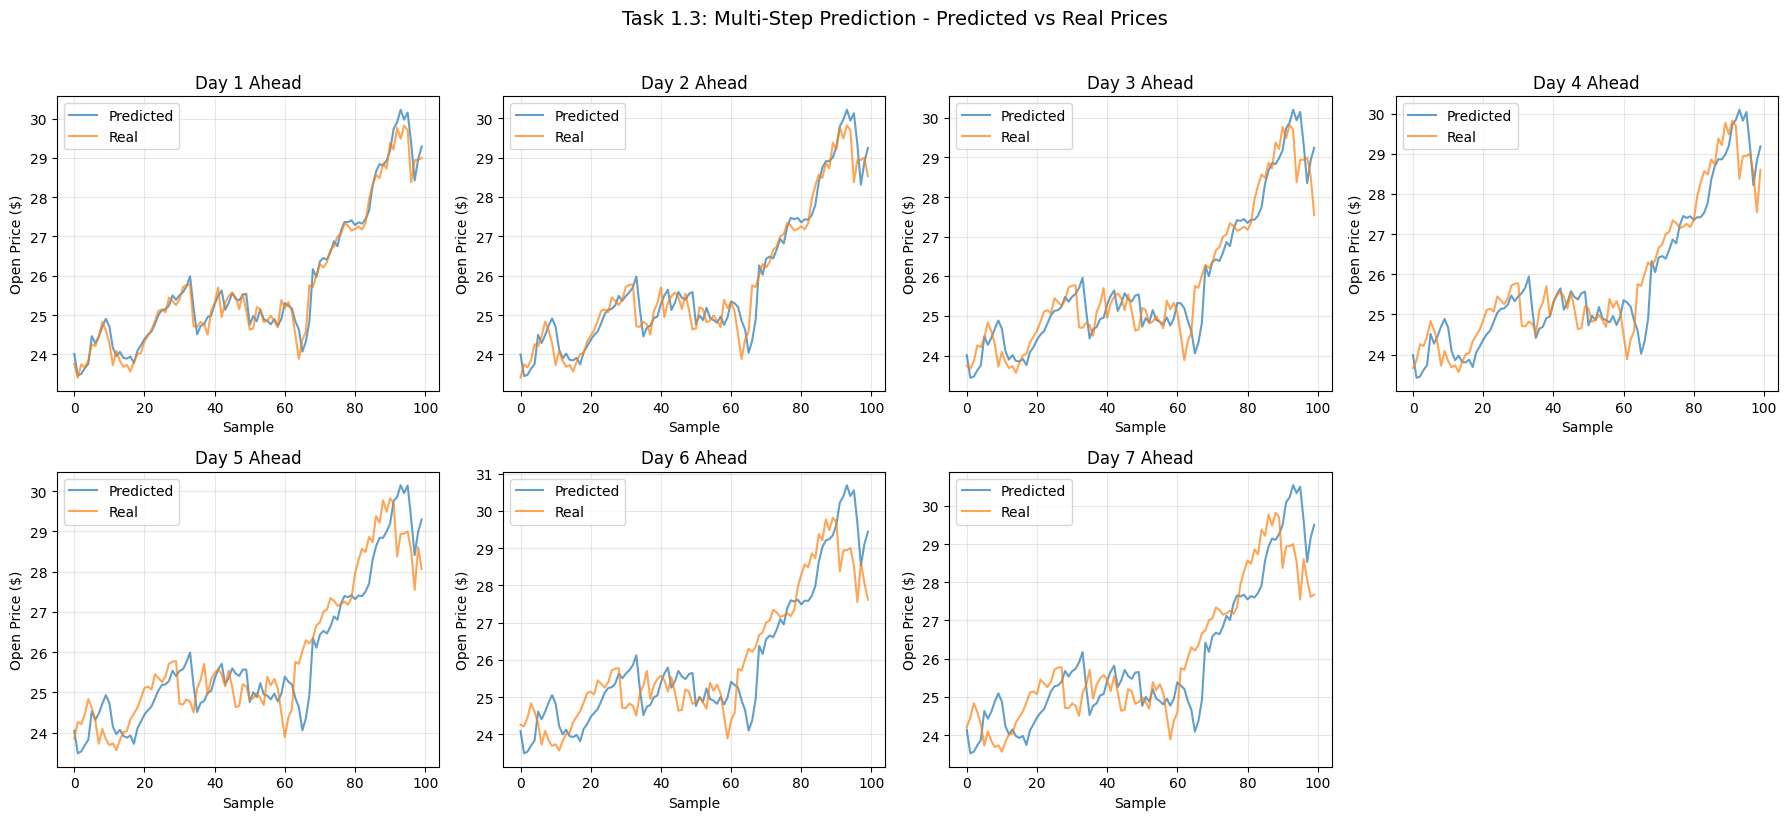

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for day in range(k_multistep):
    y_pred_denorm_day = y_pred_norm_m[:, day].copy()
    y_test_denorm_day = y_test_m[:, day].copy()
    
    for i in range(len(y_pred_denorm_day)):
        open_min = np.min(X_test_m[i, :, 1])
        open_max = np.max(X_test_m[i, :, 1])
        y_pred_denorm_day[i] = y_pred_norm_m[i, day] * (open_max - open_min) + open_min
    
    n_samples = min(100, len(y_pred_denorm_day))
    axes[day].plot(y_pred_denorm_day[:n_samples], label='Predicted', alpha=0.7)
    axes[day].plot(y_test_denorm_day[:n_samples], label='Real', alpha=0.7)
    axes[day].set_title(f'Day {day+1} Ahead')
    axes[day].set_xlabel('Sample')
    axes[day].set_ylabel('Open Price ($)')
    axes[day].legend()
    axes[day].grid(alpha=0.3)

axes[7].axis('off')

plt.suptitle('Task 1.3: Multi-Step Prediction - Predicted vs Real Prices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Task 2.1: Vietnam Multi-Feature Extension

In [25]:
data_vn = pd.read_csv('./ACB-VNINDEX-History.csv')
print("Vietnam Stock Data (ACB)")
print(f"Shape: {data_vn.shape}")
data_vn.head()

Vietnam Stock Data (ACB)
Shape: (4052, 7)


,Unnamed: 0,Open,High,Low,Close,Volume,TradingDate
0,0,5050.0,8234.0,6532.0,7147.0,56500,2006-11-21
1,1,6038.0,7861.0,7136.0,7394.0,62300,2006-11-22
2,2,6093.0,7959.0,7136.0,7597.0,69900,2006-11-23
3,3,5928.0,8344.0,7685.0,8058.0,63600,2006-11-24
4,4,6203.0,8860.0,7410.0,8058.0,42400,2006-11-27


In [27]:
data_vn.info()
data_vn = data_vn.rename(columns={'TradingDate': 'Date'})
print("\nData columns:", data_vn.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 4052 entries, 0 to 4051
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  4052 non-null   int64  
 1   Open        4052 non-null   float64
 2   High        4052 non-null   float64
 3   Low         4052 non-null   float64
 4   Close       4052 non-null   float64
 5   Volume      4052 non-null   int64  
 6   Date        4052 non-null   str    
dtypes: float64(4), int64(2), str(1)
memory usage: 221.7 KB

Data columns: ['Unnamed: 0', 'Open', 'High', 'Low', 'Close', 'Volume', 'Date']


In [28]:
df_vn = data_vn.copy()
feature_columns_vn = ['Low', 'Open', 'Volume', 'High', 'Close']
num_features_vn = len(feature_columns_vn)
window_size_vn = 30

X_data_vn = []
y_data_vn = []

for i in range(1, len(df_vn) - window_size_vn - 1):
    data_feature = []
    
    for j in range(window_size_vn):
        data_feature.append(df_vn[feature_columns_vn].iloc[i + j].values)
    
    data_label = df_vn['Open'].iloc[i + window_size_vn]
    
    X_data_vn.append(np.array(data_feature))
    y_data_vn.append(np.array(data_label))

X_data_vn = np.array(X_data_vn)
y_data_vn = np.array(y_data_vn)
print(f"Total samples: {len(X_data_vn)}")

Total samples: 4020


In [29]:
X_train_vn, X_test_vn, y_train_vn, y_test_vn = train_test_split(X_data_vn, y_data_vn, test_size=0.2, shuffle=False)
X_train_vn, X_val_vn, y_train_vn, y_val_vn = train_test_split(X_train_vn, y_train_vn, test_size=0.2, shuffle=False)

X_train_vn = np.array(X_train_vn)
X_val_vn = np.array(X_val_vn)
X_test_vn = np.array(X_test_vn)
y_train_vn = np.array(y_train_vn)
y_val_vn = np.array(y_val_vn)
y_test_vn = np.array(y_test_vn)

print("Shape of training set:", X_train_vn.shape)
print("Shape of validation set:", X_val_vn.shape)
print("Shape of test set:", X_test_vn.shape)
print("Number of features:", X_train_vn.shape[2])

Shape of training set: (2572, 30, 5)
Shape of validation set: (644, 30, 5)
Shape of test set: (804, 30, 5)
Number of features: 5


In [30]:
def normalize_multifeature_vn(X, y):
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    for i in range(len(X)):
        for f in range(X.shape[2]):
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            if denom == 0:
                X_norm[i, :, f] = 0
            else:
                X_norm[i, :, f] = (X[i, :, f] - min_val) / denom
        open_min = np.min(X[i, :, 1])
        open_max = np.max(X[i, :, 1])
        open_denom = open_max - open_min
        if open_denom == 0:
            y_norm[i] = 0
        else:
            y_norm[i] = (y[i] - open_min) / open_denom
    return X_norm, y_norm

X_train_norm_vn, y_train_norm_vn = normalize_multifeature_vn(X_train_vn, y_train_vn)
X_val_norm_vn, y_val_norm_vn = normalize_multifeature_vn(X_val_vn, y_val_vn)

In [31]:
model_vn = tf.keras.Sequential()
model_vn.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size_vn, num_features_vn), padding='same'))
model_vn.add(MaxPooling1D(pool_size=2))
model_vn.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model_vn.add(MaxPooling1D(2))
model_vn.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model_vn.add(MaxPooling1D(2))
model_vn.add(Flatten())
model_vn.add(Dense(100, activation='relu'))
model_vn.add(Dense(1))

model_vn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history_vn = model_vn.fit(X_train_norm_vn, y_train_norm_vn, validation_data=(X_val_norm_vn, y_val_norm_vn), epochs=5, batch_size=512)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 15.4849 - mse: 15.4849 - val_loss: 0.4202 - val_mse: 0.4202
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2629 - mse: 0.2629 - val_loss: 0.1421 - val_mse: 0.1421
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2020 - mse: 0.2020 - val_loss: 0.1714 - val_mse: 0.1714
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1790 - mse: 0.1790 - val_loss: 0.1149 - val_mse: 0.1149
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1561 - mse: 0.1561 - val_loss: 0.0903 - val_mse: 0.0903


In [32]:
X_test_norm_vn, y_test_norm_vn = normalize_multifeature_vn(X_test_vn, y_test_vn)
y_pred_norm_vn = model_vn.predict(X_test_norm_vn)
mse_vn = mean_squared_error(y_pred_norm_vn, y_test_norm_vn)
print(f"MSE on the Vietnam test set: {mse_vn}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MSE on the Vietnam test set: 0.0937511439040816


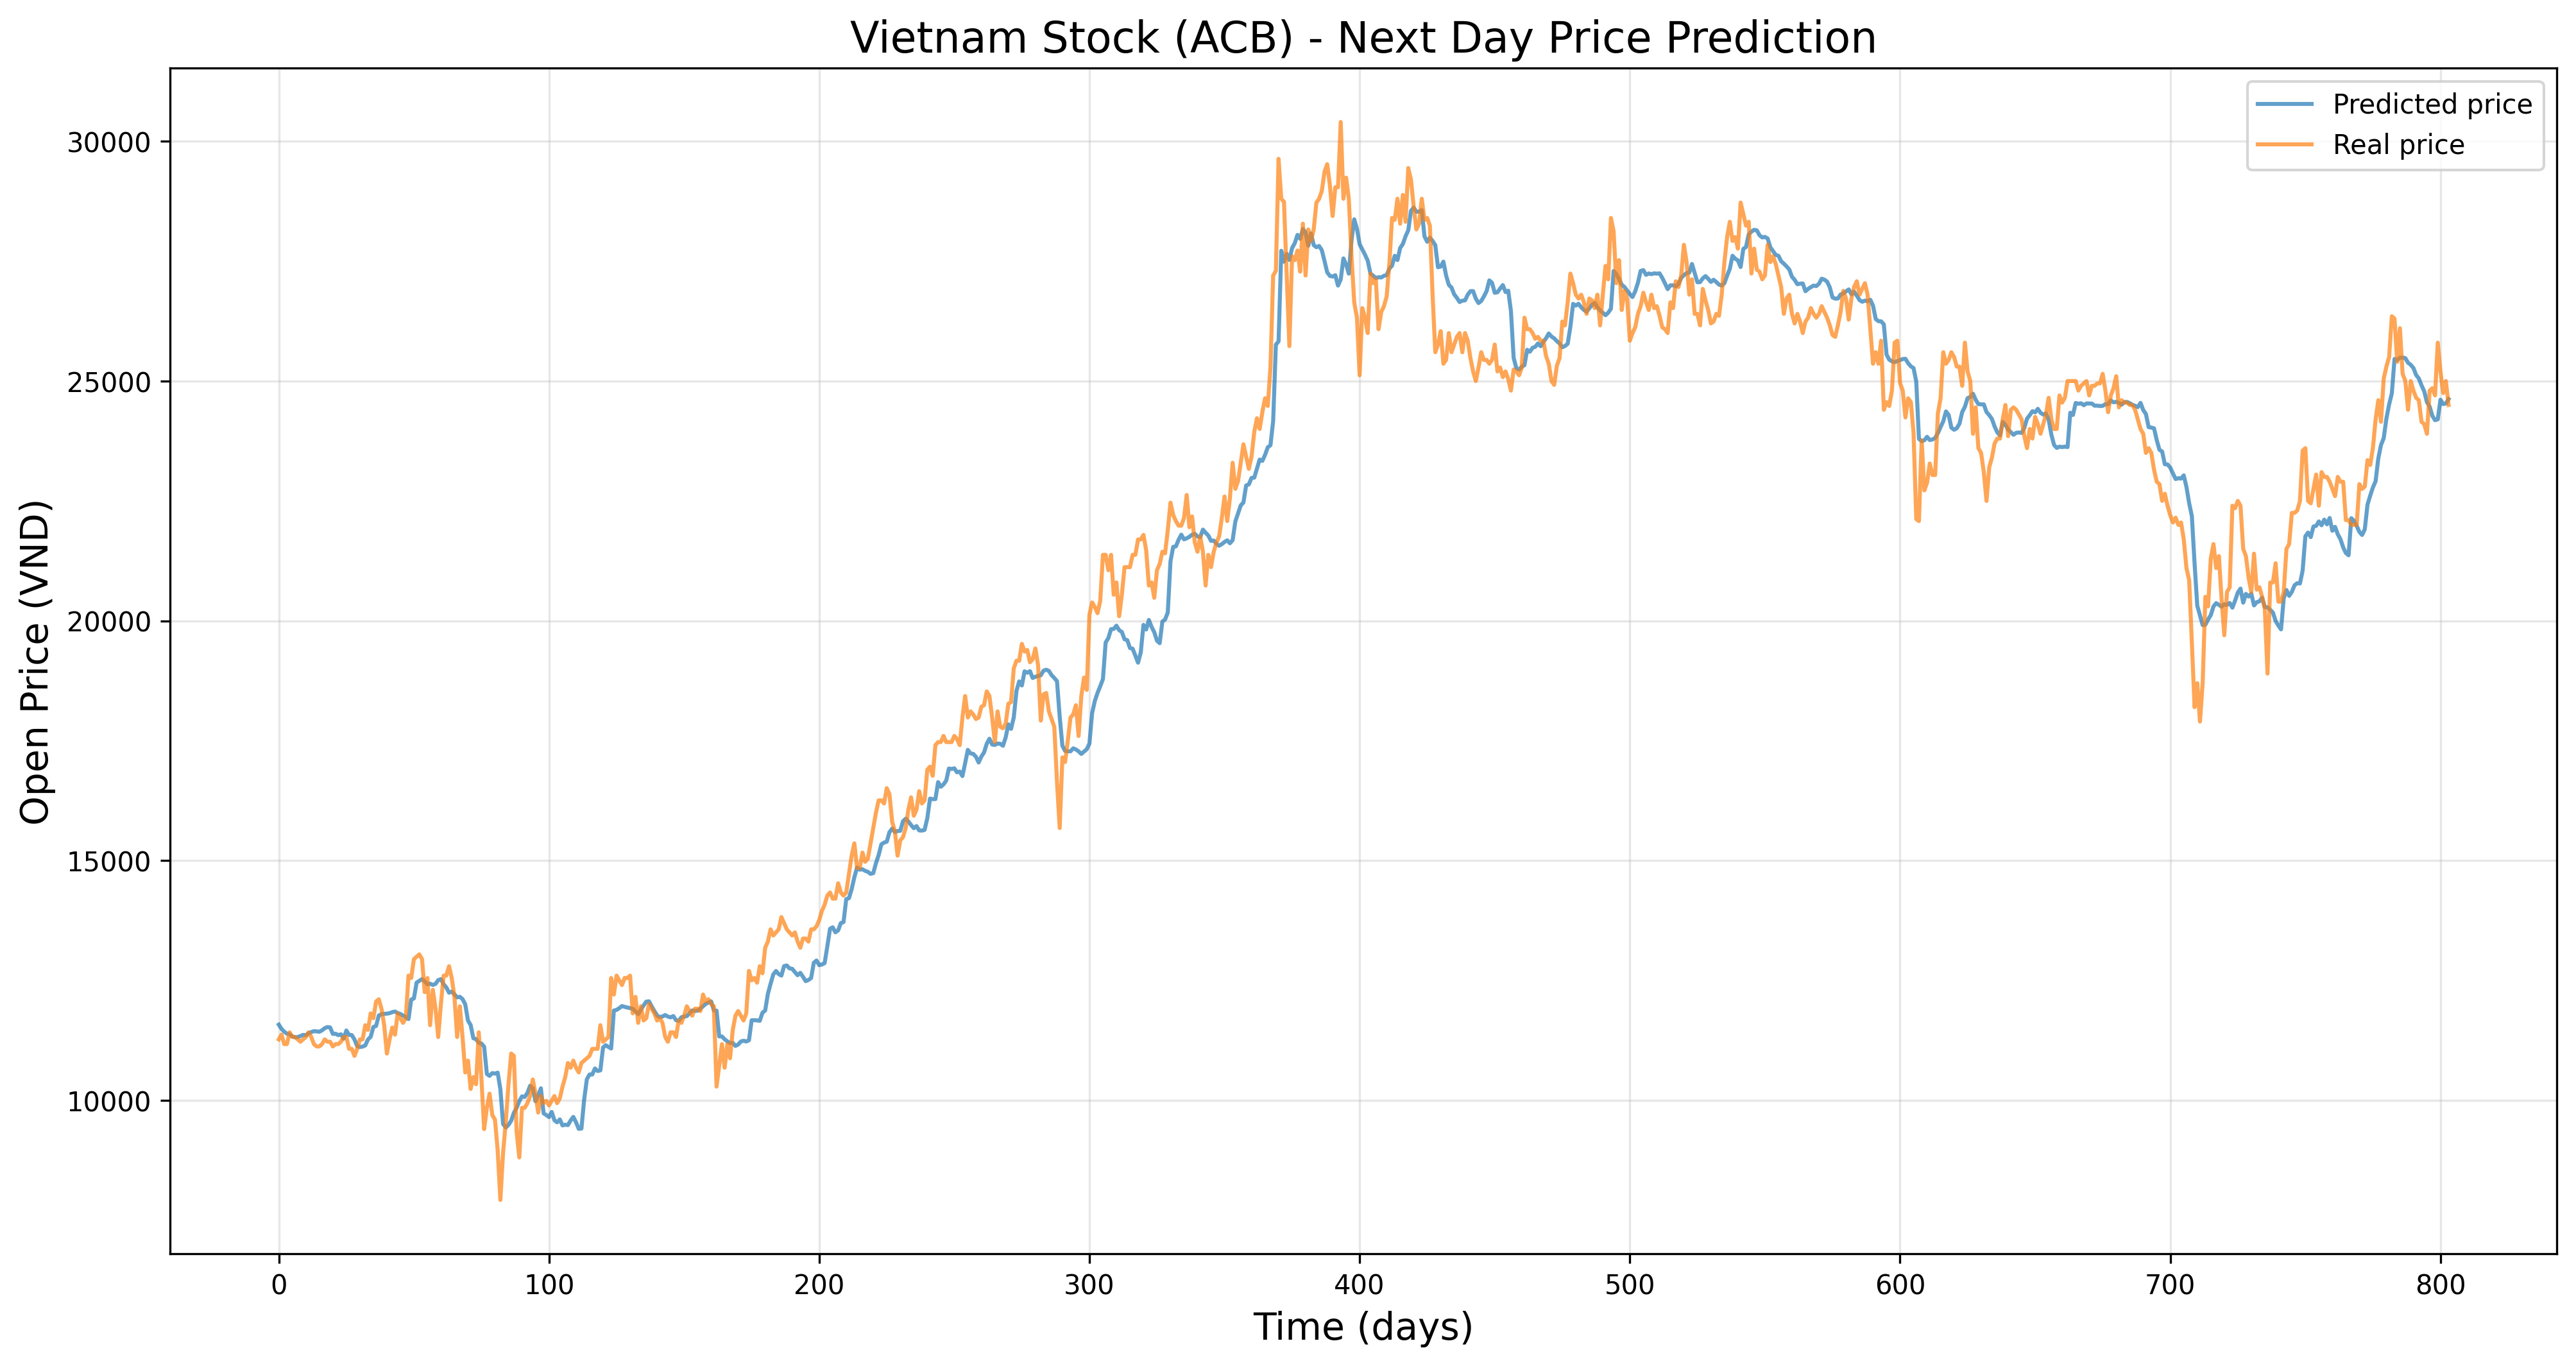

In [33]:
y_pred_denorm_vn = y_pred_norm_vn.copy()
for i in range(len(y_pred_denorm_vn)):
    open_min = np.min(X_test_vn[i, :, 1])
    open_max = np.max(X_test_vn[i, :, 1])
    y_pred_denorm_vn[i] = y_pred_norm_vn[i] * (open_max - open_min) + open_min

plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm_vn, label='Predicted price', alpha=0.7)
plt.plot(y_test_vn, label='Real price', alpha=0.7)
plt.title('Vietnam Stock (ACB) - Next Day Price Prediction', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open Price (VND)', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [34]:
print("\n=== Task 2.1 vs Task 1.1 Comparison ===")
print(f"Task 1.1 (AAPL) MSE: 0.0607")
print(f"Task 2.1 (ACB Vietnam) MSE: {mse_vn:.6f}")
print("\nObservation: MSE is higher for Vietnam market due to different market characteristics and less data normalization.")



=== Task 2.1 vs Task 1.1 Comparison ===
Task 1.1 (AAPL) MSE: 0.0607
Task 2.1 (ACB Vietnam) MSE: 0.093751

Observation: MSE is higher for Vietnam market due to different market characteristics and less data normalization.
